# **Projektowanie Leków -- Uczenie Maszynowe**


## Przygotowanie i importowanie pakietów

Wykonaj poniższe komórki, żeby zainstalować bibliotekę RDKit i zaimportować wszystkie potrzebne pakiety

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 14.4 MB/s eta 0:00:00


In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rdkit
from typing import Dict
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdMolAlign
from rdkit import RDConfig
from rdkit.Chem.FeatMaps import FeatMaps

## Pobranie Danych

Dane pobierzemy z internetu z użyciem komendy `wget`

In [3]:
!wget https://raw.githubusercontent.com/dgront/chem-ml/refs/heads/main/INPUTS/tdcommons-data/cyp1a2_veith.tab

--2025-12-13 23:10:09--  https://raw.githubusercontent.com/dgront/chem-ml/refs/heads/main/INPUTS/tdcommons-data/cyp1a2_veith.tab
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 760372 (743K) [text/plain]
Saving to: ‘cyp1a2_veith.tab’

cyp1a2_veith.tab    100%[===================>] 742.55K  --.-KB/s    in 0.04s   

2025-12-13 23:10:10 (16.3 MB/s) - ‘cyp1a2_veith.tab’ saved [760372/760372]



Wykonaj poniższą komendę, żeby wyświetlić początek pliku

In [4]:
!head cyp1a2_veith.tab

Drug_ID	Drug	Y
6602638.0	"CCCC(=O)Nc1ccc(N2CCN(CC)CC2)c(Cl)c1.Cl"	0
644510.0	"O=c1[nH]c2cc3c(cc2cc1CN(CCCO)Cc1nnnn1Cc1ccc(F)cc1)OCO3"	1
1960010.0	"CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21"	1
644675.0	"CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1"	1
644851.0	"Clc1ccccc1-c1nc(-c2ccccc2)n[nH]1"	1
644968.0	"COc1ccccc1CNC(=O)Cn1nnc(-c2ccncc2)n1"	1
6602688.0	"Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c(Cl)c1"	1
5768708.0	"COc1ccc(/C(O)=C2/C(=O)C(=O)N(CCCC(=O)O)C2c2ccc(OC)cc2)cc1"	0
645323.0	"COc1ccc(Nc2nc(N)nc(CSc3n[nH]c(-c4ccccc4)n3)n2)cc1"	1


## **Zadanie 1:** Załadowanie i przygotowanie danych

### **Zadanie 1.0**
Wczytaj dane z pobranego pliku `./data.tab` do obiektu `data` typu `DataFrame` (z biblioteki `pandas`). Użyj w tym celu funkcji `read_csv()`. Nazwij kolumny `id`, `smiles` i `label`. Wyświetl tabelę

In [7]:
# ROZWIĄZANIE
data = pd.read_csv('cyp1a2_veith.tab', sep='\t', names=['id', 'smiles', 'label'], skiprows=1)
print(data.shape)

(12579, 3)


### **Zadanie 1.1**

Wyświetl 10 pierwszych wierszy z `data`

In [8]:
# ROZWIĄZANIE
display(data.head(n=11))

,id,smiles,label
0,6602638.0,CCCC(=O)Nc1ccc(N2CCN(CC)CC2)c(Cl)c1.Cl,0
1,644510.0,O=c1[nH]c2cc3c(cc2cc1CN(CCCO)Cc1nnnn1Cc1ccc(F)...,1
2,1960010.0,CCN1C(=O)/C(=C2\SC(=S)N(CCCOC)C2=O)c2ccccc21,1
3,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,1
4,644851.0,Clc1ccccc1-c1nc(-c2ccccc2)n[nH]1,1
5,644968.0,COc1ccccc1CNC(=O)Cn1nnc(-c2ccncc2)n1,1
6,6602688.0,Br.N=c1n(CCN2CCOCC2)c2ccccc2n1CC(=O)c1ccc(Cl)c...,1
7,5768708.0,COc1ccc(/C(O)=C2/C(=O)C(=O)N(CCCC(=O)O)C2c2ccc...,0
8,645323.0,COc1ccc(Nc2nc(N)nc(CSc3n[nH]c(-c4ccccc4)n3)n2)cc1,1
9,645573.0,CCN(CC)C(=O)CSc1nnc(-c2cc3ccccc3cc2O)n1CC,1


### **Zadanie 1.2**

Załaduj do RDKit molekuły z wierszy 0 i 10000 i wyświetl ich wzory strukturalne

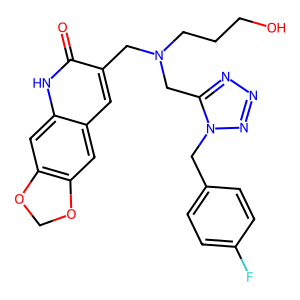

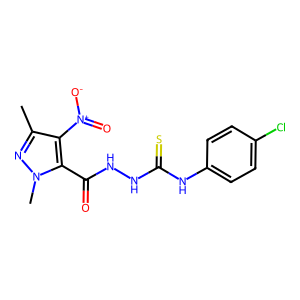

In [9]:
mol0_smiles = data.loc[1, 'smiles']
mol10000_smiles = data.loc[10000, 'smiles']

molecules_0 = rdkit.Chem.MolFromSmiles(mol0_smiles)
molecules_10000 = rdkit.Chem.MolFromSmiles(mol10000_smiles)

display(Draw.MolToImage(molecules_0))
display(Draw.MolToImage(molecules_10000))

### **Zadanie 1.3**

Utwórz listę `molecules` zawierającą molekuły utworzone ze SMILES-ów z data z wykorzystaniem RDKit

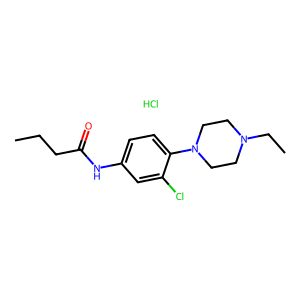

In [10]:
# ROZWIAZANIE
molecules = [rdkit.Chem.MolFromSmiles(smiles) for smiles in data['smiles']]
molecules = [mol for mol in molecules if mol is not None]

# Sanity check
display(Draw.MolToImage(molecules[0]))

## **Zadanie 2**: Uzyskanie *features* dla jednej molekuły

Sieć neuronowa potrzebuje odpowiednio przygotowanych danych. My zbudujemy bardzo prostą sieć, która na wejściu przyjmować będzie:
- liczby poszczególnych atomów
- liczby określonych *features* z RDKita

Przyjmijmy, że wektor dla pojedyńczej molekuły będzie mieć na kolejnych miejscach liczby odpowiednio:
- donorów
- akceptorów
- centrów hydrofobowych
- atomów węgla
- atomów azotu
- atomów tlenu
- atomów wodoru

### **Zadanie 2.1**

Zapisz pierwszą (o indeksie 0) molekułę z `molecules` do zmiennej `mol0`

In [11]:
# ROZWIĄZANIE
mol0 = molecules[0]

### **Zadanie 2.2**

Korzystając z funkcji  `AllChem.BuildFeatureFactory()` zbuduj obiekt `feature_factory` i wypisz listę wszystkich chemicznych *featrues* (patrz: ostatnie zajęcia)

In [12]:
# ROZWIĄZANIE
feature_factory = AllChem.BuildFeatureFactory(os.path.join(RDConfig.RDDataDir,'BaseFeatures.fdef'))
features = feature_factory.GetFeaturesForMol(mol0)

for ftype in feature_factory.GetFeatureFamilies():
    print(ftype)

Donor
Acceptor
NegIonizable
PosIonizable
ZnBinder
Aromatic
Hydrophobe
LumpedHydrophobe


### **Zadanie 2.3**
Wyznacz i wypisz liczbę poszczególnych chemicznych features w `mol0`

In [13]:
## ROZWIĄZANIE
features_mol0 = feature_factory.GetFeaturesForMol(mol0)
feature_counts: Dict = {}

for feat in features_mol0:
    feature_type = feat.GetFamily()
    feature_counts[feature_type] = feature_counts.get(feature_type, 0) + 1

for ftype, count in feature_counts.items():
    print(f"{ftype}: {count}")

Donor: 2
Acceptor: 1
PosIonizable: 1
Aromatic: 1
Hydrophobe: 3
LumpedHydrophobe: 1


### **Zadanie 2.4**

Wyznacz i wypisz liczbę atomów węgla, tlenu, azotu, fluoru, siarki i chloru w cząteczce `mol`

In [18]:
# ROZWIĄZANIE
atom_counts = {"C": 0, "O": 0, "N": 0, "F": 0, "S": 0, "Cl": 0}

for atom in mol0.GetAtoms():
    symbol = atom.GetSymbol()
    if symbol in atom_counts:
        atom_counts[symbol] += 1

for symbol, count in atom_counts.items():
    print(f"  {symbol}: {count}")

  C: 16
  O: 1
  N: 3
  F: 0
  S: 0
  Cl: 2


## **Zadanie 3:** Przygotowanie danych wejściowych

Bazując na poprzednim zadaniu przygotuj dane wejściowe do sieci. Dla każdej molekuły powinieneś mieć odpowiednie liczby *features* z RDKita oraz liczby określonych atomów. Jednocześnie powinieneś mieć ułożone w tej samej kolejności etykiety (ostatni rząd w `data`).

Dane możesz umieścić np w dwuwymiarowej liście, `ndarray`, albo po prostu dodać kolumny z nowymi parametrami do `data`. Póki co nie rozdzielaj danych wejściowych i etykiet, bo będzie je jescze trzeba przemieszać i podzielić na dane treningowe i testowe.

In [22]:
def is_ring_aromatic(mol, bond_ring_indices):
    """ Checks if a specific ring (defined by bond indices) is aromatic.
    Returns True if ALL bonds in the ring are aromatic.
    """
    for bond_idx in bond_ring_indices:
        if not mol.GetBondWithIdx(bond_idx).GetIsAromatic():
            return False
    return True


def get_ring_features(mol):
    ri = mol.GetRingInfo()
    bond_rings = ri.BondRings()
    num_rings = ri.NumRings()
    num_aromatic = 0
    for ring in bond_rings:
        if is_ring_aromatic(mol, ring):
            num_aromatic += 1

    num_aliphatic = num_rings - num_aromatic

    return {
        "Num_Rings_Total": num_rings,
        "Num_Rings_Aromatic": num_aromatic,
        "Num_Rings_Aliphatic": num_aliphatic
    }

x_map = {
    'atomic_num': list(range(0, 119)),
    'chirality': [
        'CHI_UNSPECIFIED', 'CHI_TETRAHEDRAL_CW', 'CHI_TETRAHEDRAL_CCW', 'CHI_OTHER',
        'CHI_TETRAHEDRAL', 'CHI_ALLENE', 'CHI_SQUAREPLANAR', 'CHI_TRIGONALBIPYRAMIDAL', 'CHI_OCTAHEDRAL',
    ],
    'degree': list(range(0, 11)),
    'formal_charge': list(range(-5, 7)),
    'num_hs': list(range(0, 9)),
    'num_radical_electrons': list(range(0, 5)),
    'hybridization': [
        'UNSPECIFIED', 'S', 'SP', 'SP2', 'SP3', 'SP3D', 'SP3D2', 'OTHER',
    ],
    'is_aromatic': [False, True],
    'is_in_ring': [False, True],
}

e_map = {
    'bond_type': [
        'UNSPECIFIED', 'SINGLE', 'DOUBLE', 'TRIPLE', 'QUADRUPLE', 'QUINTUPLE', 'HEXTUPLE',
        'ONEANDAHALF', 'TWOANDAHALF', 'THREEANDAHALF', 'FOURANDAHALF', 'FIVEANDAHALF',
        'AROMATIC', 'IONIC', 'HYDROGEN', 'THREECENTER', 'DATIVEONE', 'DATIVE',
        'DATIVEL', 'DATIVER', 'OTHER', 'ZERO',
    ],
    'stereo': [
        'STEREONONE', 'STEREOANY', 'STEREOZ', 'STEREOE', 'STEREOCIS', 'STEREOTRANS',
    ],
    'is_conjugated': [False, True],
}


chem_features_names = ["Donor", "Acceptor", "NegIonizable",
                       "Hydrophobe", "PosIonizable", "ZnBinder",
                       "Aromatic", "LumpedHydrophobe"]
chem_cols = [f"{feat}_Count" for feat in chem_features_names]

# Ring Features
ring_cols = ["Num_Rings_Total", "Num_Rings_Aromatic", "Num_Rings_Aliphatic"]
structural_cols = []
for key, values in x_map.items():
    for val in values:
        structural_cols.append(f"Atom_{key}_{val}")
for key, values in e_map.items():
    for val in values:
        structural_cols.append(f"Bond_{key}_{val}")

all_columns = chem_cols + ring_cols + ["Formal_Charge_Sum"] + structural_cols
processed_features_list = []

for mol in molecules:
    row_dict = {col: 0 for col in all_columns}

    if mol:
        feats = feature_factory.GetFeaturesForMol(mol)
        for feat in feats:
            ftype = feat.GetFamily()
            col_name = f"{ftype}_Count"
            if col_name in row_dict:
                row_dict[col_name] += 1

        ring_data = get_ring_features(mol)
        for k, v in ring_data.items():
            row_dict[k] = v

        row_dict["Formal_Charge_Sum"] = Chem.GetFormalCharge(mol)

        for atom in mol.GetAtoms():
            # Atomic Num
            row_dict[f"Atom_atomic_num_{atom.GetAtomicNum()}"] += 1
            # Chirality
            row_dict[f"Atom_chirality_{str(atom.GetChiralTag())}"] += 1
            # Degree
            row_dict[f"Atom_degree_{atom.GetDegree()}"] += 1
            # Formal Charge (Map specific counts)
            f_chg = atom.GetFormalCharge()
            if f_chg in x_map['formal_charge']:
                row_dict[f"Atom_formal_charge_{f_chg}"] += 1
            # Num Hs
            row_dict[f"Atom_num_hs_{atom.GetTotalNumHs()}"] += 1
            # Radical Electrons
            row_dict[f"Atom_num_radical_electrons_{atom.GetNumRadicalElectrons()}"] += 1
            # Hybridization
            row_dict[f"Atom_hybridization_{str(atom.GetHybridization())}"] += 1
            # Is Aromatic
            row_dict[f"Atom_is_aromatic_{atom.GetIsAromatic()}"] += 1
            # Is In Ring
            row_dict[f"Atom_is_in_ring_{atom.IsInRing()}"] += 1

        # Bond Properties
        for bond in mol.GetBonds():
            # Bond Type
            row_dict[f"Bond_bond_type_{str(bond.GetBondType())}"] += 1
            # Stereo
            row_dict[f"Bond_stereo_{str(bond.GetStereo())}"] += 1
            # Conjugation
            row_dict[f"Bond_is_conjugated_{bond.GetIsConjugated()}"] += 1

    row_data = [row_dict[col] for col in all_columns]
    processed_features_list.append(row_data)

feature_df = pd.DataFrame(processed_features_list, columns=all_columns)
labels_for_molecules = data["label"].astype(int).reset_index(drop=True)
feature_df["label"] = labels_for_molecules
input_data_df = feature_df

display(input_data_df.head(n=5))
print(f"Generated DataFrame shape: {input_data_df.shape}")

,Donor_Count,Acceptor_Count,NegIonizable_Count,Hydrophobe_Count,PosIonizable_Count,ZnBinder_Count,Aromatic_Count,LumpedHydrophobe_Count,Num_Rings_Total,Num_Rings_Aromatic,...,Bond_bond_type_ZERO,Bond_stereo_STEREONONE,Bond_stereo_STEREOANY,Bond_stereo_STEREOZ,Bond_stereo_STEREOE,Bond_stereo_STEREOCIS,Bond_stereo_STEREOTRANS,Bond_is_conjugated_False,Bond_is_conjugated_True,label
0,2,1,0,3,1,0,1,1,2,1,...,0,22,0,0,0,0,0,12,10,0
1,3,8,0,4,1,0,4,2,5,4,...,0,38,0,0,0,0,0,13,25,1
2,1,3,0,4,0,0,1,1,3,1,...,0,25,0,1,0,0,0,9,17,1
3,0,4,0,2,0,0,3,2,3,3,...,0,24,0,0,0,0,0,5,19,1
4,3,2,0,3,0,0,3,2,3,3,...,0,20,0,0,0,0,0,1,19,1


Generated DataFrame shape: (12579, 220)


### **Zadanie 3.1**

Obejrzyj uzyskaną tabelę danych; sprawdź czy wszystko wygląda tak jak powinno

In [23]:
# ROZWIAZANIE
display(input_data_df.head())

,Donor_Count,Acceptor_Count,NegIonizable_Count,Hydrophobe_Count,PosIonizable_Count,ZnBinder_Count,Aromatic_Count,LumpedHydrophobe_Count,Num_Rings_Total,Num_Rings_Aromatic,...,Bond_bond_type_ZERO,Bond_stereo_STEREONONE,Bond_stereo_STEREOANY,Bond_stereo_STEREOZ,Bond_stereo_STEREOE,Bond_stereo_STEREOCIS,Bond_stereo_STEREOTRANS,Bond_is_conjugated_False,Bond_is_conjugated_True,label
0,2,1,0,3,1,0,1,1,2,1,...,0,22,0,0,0,0,0,12,10,0
1,3,8,0,4,1,0,4,2,5,4,...,0,38,0,0,0,0,0,13,25,1
2,1,3,0,4,0,0,1,1,3,1,...,0,25,0,1,0,0,0,9,17,1
3,0,4,0,2,0,0,3,2,3,3,...,0,24,0,0,0,0,0,5,19,1
4,3,2,0,3,0,0,3,2,3,3,...,0,20,0,0,0,0,0,1,19,1


### **Zadanie 3.2**

Zapisz dane do pliku `data.csv`

In [24]:
# ROZWIAZANIE
input_data_df.to_csv('data.csv', index=False)

In [25]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf /content/Projektowanie_Lekow_ML1_PyTorch.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 